# 🐾 PetGuard AI — Baseline Prototype

### Computer Vision-Based Pet Restricted-Zone Monitoring

**Course:** ITAI 1378 - Computer Vision  
**Project Tier:** Tier 1 - Object Detection Application

---

## Prototype Objective

The purpose of this notebook is to validate the first technical dependency of **PetGuard AI**:

> Can a pretrained object-detection model identify and localize dogs and cats well enough to support the initial PetGuard application pipeline?

PetGuard AI is designed to eventually follow this pipeline:

**Image / Video → Pet Detection → Restricted-Zone Reasoning → SAFE / VIOLATION → Event Log**

For the Midterm baseline, this notebook focuses on the first stage:

**Pet Image → YOLOv8n → Dog/Cat Detection → Confidence + Bounding Box**

A successful result demonstrates that pretrained object detection can provide the localization information required for the later PetGuard spatial-reasoning pipeline.

## Step 1 - Install Dependencies

PetGuard uses the **Ultralytics YOLO** framework for object detection.

For the baseline prototype, we use **YOLOv8n** with pretrained Common Objects in Context (COCO) weights rather than training a new detector from scratch.

This provides an efficient way to validate project feasibility because `dog` and `cat` are already supported object classes.

In [1]:
!pip install ultralytics

## Step 2 - Import Libraries

The baseline uses:

- **Ultralytics YOLO** for object detection
- **PyTorch** as the underlying deep-learning framework
- **OpenCV** for image processing
- **Matplotlib** for visualization
- **Pandas** for baseline result summaries

The runtime environment is also recorded because inference performance
can vary depending on the available Google Colab hardware.

In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd

### Runtime Environment

The experiment records its software and compute environment because
inference performance can vary across Google Colab sessions and
available hardware.

In [3]:
import sys
import torch
import ultralytics

print("Python:", sys.version.split()[0])
print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print(
    "Device:",
    "CUDA GPU"
    if torch.cuda.is_available()
    else "CPU"
)

Python: 3.13.15
Ultralytics: 8.4.166
PyTorch: 2.11.0+cpu
Device: CPU


> **Performance note:** Inference timing depends on the Colab runtime,
> input resolution, and available hardware. Timing observed in this
> notebook is treated as a baseline measurement rather than guaranteed
> PetGuard performance.

## Step 3 — Load Baseline Test Images from GitHub

To make the experiment reproducible, the baseline test images are stored
in the PetGuard AI GitHub repository rather than uploaded manually from
a local computer.

Four representative scenarios are used for the Midterm feasibility test:

1. **Dog on couch** - verifies dog detection.
2. **Cat on bed** - verifies cat detection.
3. **Dog and cat together** - verifies multiple supported pets can be detected in the same scene.
4. **Room with no pet** - provides a negative-control case for checking false pet detections.

These samples are intended as a small feasibility test, not as the final
evaluation dataset.

In [4]:
import urllib.request
import os

BASE_URL = (
    "https://raw.githubusercontent.com/"
    "iamhuongthn/PetGuard-AI/master/"
    "samples/images/"
)

test_images = {
    "Dog on Couch": {
        "filename": "dog_on_couch.jpg",
        "expected": {"dog"}
    },
    "Cat on Bed": {
        "filename": "cat_on_bed.jpg",
        "expected": {"cat"}
    },
    "Dog and Cat Together": {
        "filename": "dog_n_cat_together.jpg",
        "expected": {"dog", "cat"}
    },
    "Room with No Pet": {
        "filename": "room_w_no_pet.jpg",
        "expected": set()
    }
}

for scenario, info in test_images.items():
    filename = info["filename"]
    image_url = BASE_URL + filename

    urllib.request.urlretrieve(image_url, filename)

    print(
        f"{scenario}: {filename} "
        f"— downloaded: {os.path.exists(filename)}"
    )

Dog on Couch: dog_on_couch.jpg — downloaded: True
Cat on Bed: cat_on_bed.jpg — downloaded: True
Dog and Cat Together: dog_n_cat_together.jpg — downloaded: True
Room with No Pet: room_w_no_pet.jpg — downloaded: True


### Verify Baseline Test Images

Before running inference, the four downloaded images are displayed to
verify that the intended test scenarios were loaded correctly.

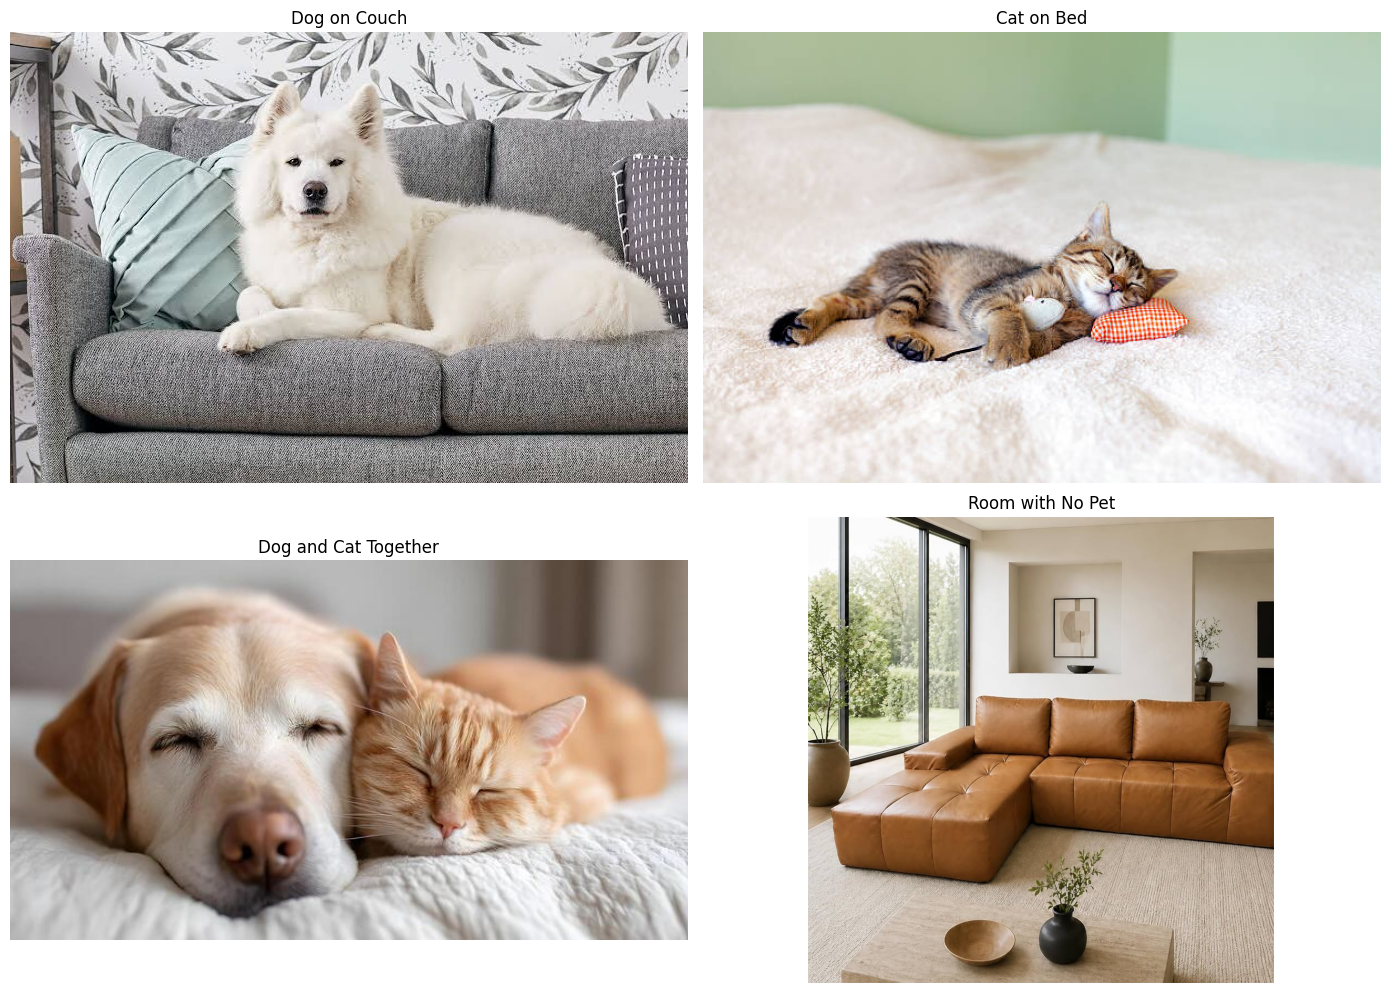

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (scenario, info) in zip(axes.flatten(), test_images.items()):
    image = cv2.imread(info["filename"])

    if image is None:
        raise ValueError(
            f"Could not load {info['filename']}"
        )

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image_rgb)
    ax.set_title(scenario)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 4 - Load the Pretrained YOLO Model

The prototype uses **YOLOv8n** initialized with pretrained COCO weights.

YOLO is appropriate for PetGuard because it provides both:

1. **Classification** - What object is present?
2. **Localization** - Where is the object?

For each detected object, YOLO returns a class label, confidence score, and bounding-box coordinates.

In [6]:
model = YOLO("yolov8n.pt")

print("YOLOv8n model loaded successfully.")

YOLOv8n model loaded successfully.


## Step 5 - Run Baseline Object Detection

Each baseline image is passed through the same pretrained YOLOv8n model.

At this stage, YOLO may detect many COCO object classes in the scene.
PetGuard will subsequently filter these detections so that only
**dog** and **cat** detections continue through the application pipeline.

In [7]:
baseline_results = {}

for scenario, info in test_images.items():

    print(f"\n{'=' * 60}")
    print(f"Scenario: {scenario}")
    print(f"{'=' * 60}")

    results = model(info["filename"])

    baseline_results[scenario] = results[0]


Scenario: Dog on Couch

image 1/1 /content/dog_on_couch.jpg: 448x640 1 dog, 1 bed, 402.7ms
Speed: 9.1ms preprocess, 402.7ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)

Scenario: Cat on Bed

image 1/1 /content/cat_on_bed.jpg: 448x640 1 cat, 1 bed, 376.1ms
Speed: 15.9ms preprocess, 376.1ms inference, 3.8ms postprocess per image at shape (1, 3, 448, 640)

Scenario: Dog and Cat Together

image 1/1 /content/dog_n_cat_together.jpg: 384x640 1 cat, 2 dogs, 523.9ms
Speed: 16.3ms preprocess, 523.9ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)

Scenario: Room with No Pet

image 1/1 /content/room_w_no_pet.jpg: 640x640 2 bowls, 1 couch, 3 potted plants, 3 vases, 962.7ms
Speed: 16.9ms preprocess, 962.7ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 640)


### Visualize YOLO Baseline Results

The following images show YOLO's raw object-detection output before
PetGuard applies pet-specific filtering or spatial reasoning.

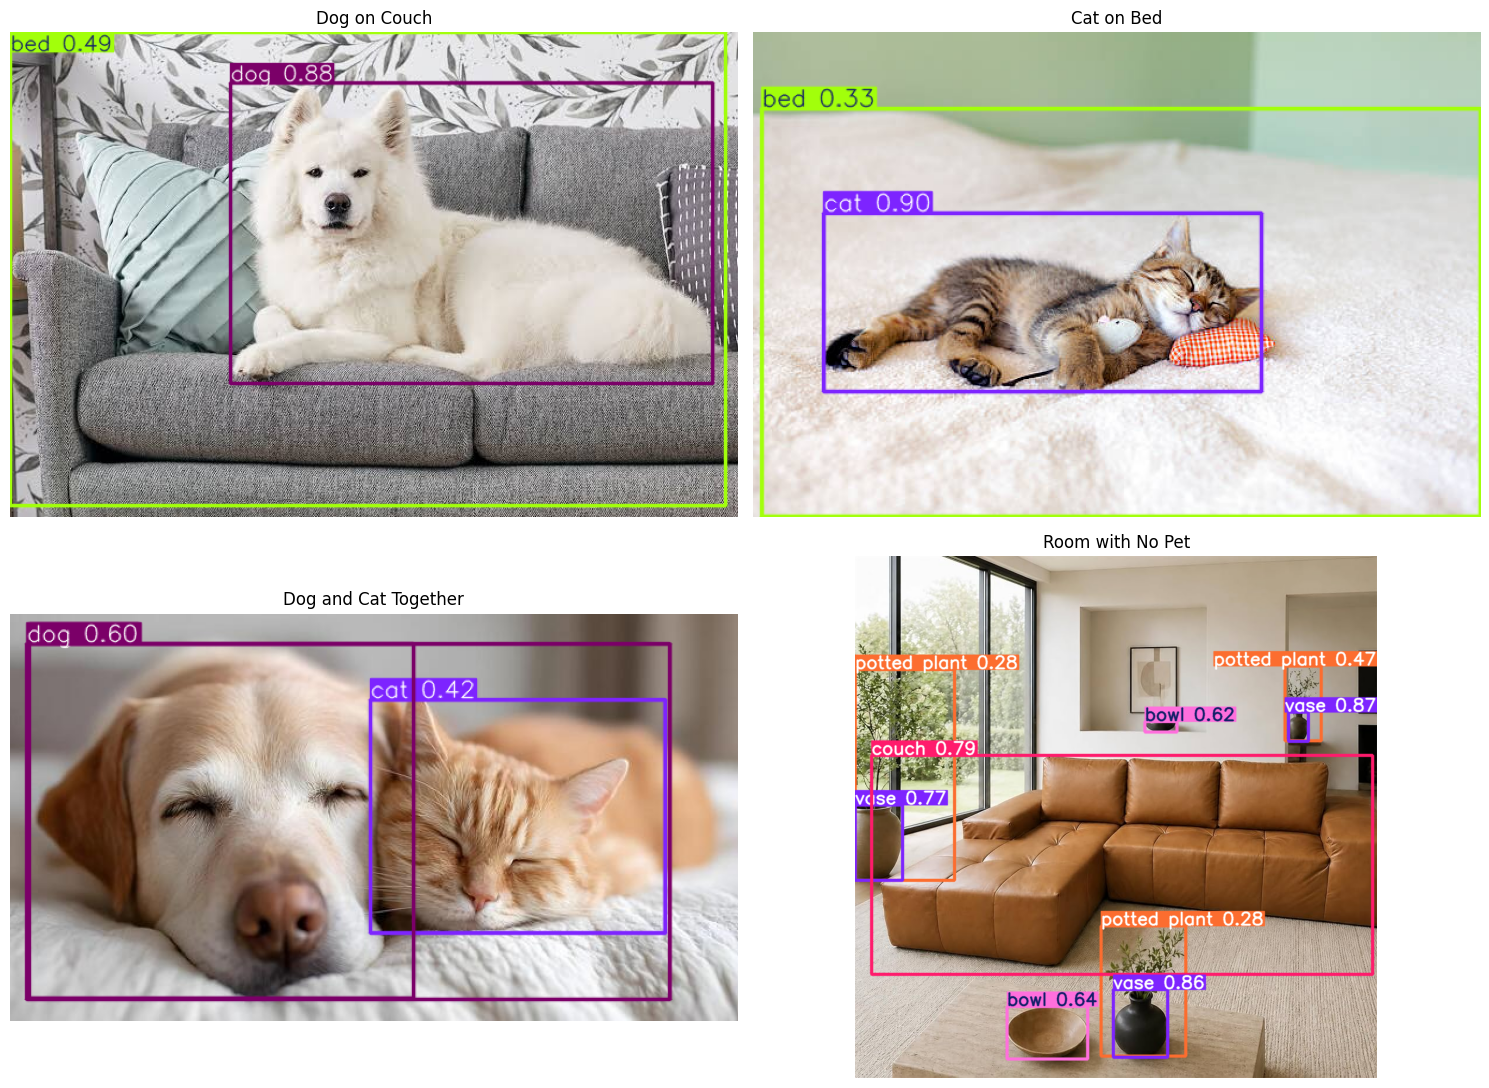

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, (scenario, result) in zip(
    axes.flatten(),
    baseline_results.items()
):
    annotated = result.plot()

    # YOLO result.plot() returns BGR
    annotated_rgb = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(annotated_rgb)
    ax.set_title(scenario)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 6 - Filter Supported Pet Classes

YOLO may recognize many objects in a home environment, but the current
PetGuard prototype supports only:

**dog** and **cat**

Therefore, detections belonging to other COCO classes are excluded from
the PetGuard decision pipeline.

For every supported pet detection, the prototype records:

- predicted class;
- confidence score; and
- bounding-box coordinates.

In [9]:
PET_CLASSES = {"dog", "cat"}

pet_results = {}

for scenario, result in baseline_results.items():

    detections = []

    for box in result.boxes:

        class_id = int(box.cls[0])
        class_name = result.names[class_id]
        confidence = float(box.conf[0])

        if class_name in PET_CLASSES:

            bbox = box.xyxy[0].tolist()

            detections.append({
                "class": class_name,
                "confidence": confidence,
                "bbox": bbox
            })

    pet_results[scenario] = detections

In [10]:
for scenario, detections in pet_results.items():

    print(f"\n--- {scenario} ---")

    if not detections:
        print("No supported pet detected.")

    else:
        for pet in detections:

            print(
                f"🐾 {pet['class'].title()} detected"
            )

            print(
                f"   Confidence: "
                f"{pet['confidence']:.2%}"
            )

            print(
                "   Bounding box:",
                [
                    round(value, 2)
                    for value in pet["bbox"]
                ]
            )


--- Dog on Couch ---
🐾 Dog detected
   Confidence: 87.90%
   Bounding box: [205.61, 47.51, 654.43, 327.19]

--- Cat on Bed ---
🐾 Cat detected
   Confidence: 90.48%
   Bounding box: [59.03, 152.66, 427.83, 302.78]

--- Dog and Cat Together ---
🐾 Dog detected
   Confidence: 59.86%
   Bounding box: [14.19, 26.39, 566.47, 331.56]
🐾 Dog detected
   Confidence: 46.82%
   Bounding box: [16.43, 26.22, 346.86, 330.45]
🐾 Cat detected
   Confidence: 42.06%
   Bounding box: [309.46, 74.33, 562.19, 274.34]

--- Room with No Pet ---
No supported pet detected.


## Step 7 - Compare Expected vs. Detected Pet Classes

Because the purpose of this Midterm experiment is feasibility testing,
each image has known expected pet classes.

The detected pet classes are compared against those expectations.

This is a **class-coverage check**, not an object-count accuracy test.

For example, if an image contains one dog and one cat but YOLO produces
two dog detections and one cat detection, the expected classes are still
covered, but the duplicate detection remains an important limitation.

A larger Final evaluation will separately examine false positives,
missed detections, duplicate detections, and overall detection quality.

In [11]:
baseline_summary = []

for scenario, info in test_images.items():

    expected = info["expected"]

    detected = {
        pet["class"]
        for pet in pet_results[scenario]
    }

    status = "PASS" if expected == detected else "REVIEW"

    baseline_summary.append({
        "Scenario": scenario,
        "Expected": (
            ", ".join(sorted(expected))
            if expected
            else "None"
        ),
        "Detected": (
            ", ".join(sorted(detected))
            if detected
            else "None"
        ),
        "Class Coverage": status
    })

In [12]:
summary_df = pd.DataFrame(baseline_summary)

display(summary_df)

,Scenario,Expected,Detected,Class Coverage
0,Dog on Couch,dog,dog,PASS
1,Cat on Bed,cat,cat,PASS
2,Dog and Cat Together,"cat, dog","cat, dog",PASS
3,Room with No Pet,None,None,PASS


### Baseline Observation - Multi-Pet Scene

The mixed-pet test produced an important result.

YOLO detected both expected pet classes:

- **dog**
- **cat**

However, the model produced **two dog detections and one cat detection**
in a scene expected to contain one dog and one cat.

This means the **class-coverage check passed**, because both expected
classes were detected, but the result also reveals a possible duplicate
or overlapping dog detection.

The confidence scores were also lower in the more complex multi-pet scene:

- **Dog on couch:** approximately 87.9%
- **Cat on bed:** approximately 90.5%
- **Multi-pet scene:** approximately 59.9%, 46.8%, and 42.1%

This suggests that scene complexity may affect detection confidence and
object-level behavior.

Therefore, detecting the correct classes alone is not sufficient to
establish PetGuard's reliability. The Final evaluation will also examine
false positives, duplicate detections, missed detections, and performance
under more challenging conditions.

### Confidence Threshold Tradeoff

The multi-pet test demonstrates why PetGuard should not select a
confidence threshold arbitrarily.

A confidence threshold determines which YOLO detections are accepted by
the application.

For example, consider the detections observed in the current multi-pet
test:

| Detection | Confidence |
|---|---:|
| Dog | ~59.9% |
| Dog | ~46.8% |
| Cat | ~42.1% |

If PetGuard used a **50% confidence threshold**, the two detections below
50% would be removed.

This could help suppress the lower-confidence duplicate dog detection,
but it would also remove the cat detection.

Therefore, increasing the confidence threshold may reduce uncertain or
false detections while simultaneously increasing the risk of missing
valid pets.

This creates an important engineering tradeoff:

**Higher threshold → fewer low-confidence detections, but potentially more missed pets**

**Lower threshold → better chance of detecting pets, but potentially more false or duplicate detections**

For PetGuard, missing a pet and generating an unnecessary alert have
different consequences. Therefore, the operating threshold should be
selected using measured performance on a larger evaluation set rather
than chosen arbitrarily.

The Final evaluation will compare threshold settings using metrics such
as:

- pet detection recall;
- false-positive detections;
- duplicate detections; and
- downstream SAFE / VIOLATION decision accuracy.

#### Illustrative Threshold Analysis

To demonstrate the confidence-threshold tradeoff using our actual
baseline results, we compare several possible thresholds on the
**Dog and Cat Together** scenario.

This experiment does **not** select the final PetGuard confidence
threshold. Instead, it illustrates how changing the threshold affects
which detections are retained.

The goal is to understand the tradeoff between suppressing uncertain
detections and accidentally removing valid pets.

In [13]:
thresholds = [0.30, 0.40, 0.50, 0.60]

scenario = "Dog and Cat Together"
detections = pet_results[scenario]

for threshold in thresholds:

    accepted = [
        pet
        for pet in detections
        if pet["confidence"] >= threshold
    ]

    print(f"\nThreshold: {threshold:.0%}")

    if not accepted:
        print("  No pet detections retained.")
        continue

    for pet in accepted:
        print(
            f"  {pet['class'].title()} "
            f"— {pet['confidence']:.2%}"
        )


Threshold: 30%
  Dog — 59.86%
  Dog — 46.82%
  Cat — 42.06%

Threshold: 40%
  Dog — 59.86%
  Dog — 46.82%
  Cat — 42.06%

Threshold: 50%
  Dog — 59.86%

Threshold: 60%
  No pet detections retained.


#### Threshold Analysis Observation

The threshold comparison reveals an important tradeoff.

At **30–40%**, both expected pet classes are retained, but the possible
duplicate dog detection is also retained.

At **50%**, the lower-confidence detections are removed. However, this
also removes the valid cat detection, leaving only the highest-confidence
dog detection.

At **60%**, none of the pet detections in this multi-pet example would
be retained.

This demonstrates that simply increasing the confidence threshold is
not necessarily a solution to uncertain or duplicate detections.

A higher threshold may reduce false or duplicate detections, but it can
also reduce **recall** by removing valid pets.

Therefore, the final PetGuard operating threshold will be selected using
a larger evaluation set rather than chosen from a single example.

### Baseline Detection Summary

The following table summarizes the pet detections observed during the
four-scenario Midterm feasibility test.

This summary is descriptive only. With four test images, it should not
be interpreted as a statistically meaningful accuracy measurement.

In [14]:
baseline_metrics = []

for scenario, detections in pet_results.items():

    confidences = [
        pet["confidence"]
        for pet in detections
    ]

    baseline_metrics.append({
        "Scenario": scenario,
        "Pet Detections": len(detections),
        "Highest Confidence": (
            max(confidences)
            if confidences
            else None
        ),
        "Lowest Confidence": (
            min(confidences)
            if confidences
            else None
        )
    })

metrics_df = pd.DataFrame(baseline_metrics)

metrics_df["Highest Confidence"] = (
    metrics_df["Highest Confidence"]
    .map(
        lambda x:
        f"{x:.2%}" if pd.notna(x)
        else "N/A"
    )
)

metrics_df["Lowest Confidence"] = (
    metrics_df["Lowest Confidence"]
    .map(
        lambda x:
        f"{x:.2%}" if pd.notna(x)
        else "N/A"
    )
)

display(metrics_df)

,Scenario,Pet Detections,Highest Confidence,Lowest Confidence
0,Dog on Couch,1,87.90%,87.90%
1,Cat on Bed,1,90.48%,90.48%
2,Dog and Cat Together,3,59.86%,42.06%
3,Room with No Pet,0,N/A,N/A


### What We Learned From the Baseline

The four-scenario feasibility experiment produced several useful
observations:

**1. Pretrained pet detection is feasible.**  
YOLOv8n successfully detected the expected dog and cat classes in the
single-pet test images without custom model training.

**2. Scene complexity affects detection behavior.**  
The multi-pet scene produced lower confidence scores and an additional
dog detection. This shows why class coverage alone is not sufficient
to evaluate object-detection quality.

**3. Confidence thresholds create a tradeoff.**  
Increasing the threshold can suppress uncertain detections, but it may
also remove valid pets. The operating threshold therefore needs to be
selected using a larger evaluation set.

**4. Negative examples are important.**  
YOLO detected several household objects in the no-pet image, but
PetGuard's dog/cat filter correctly prevented those objects from entering
the pet-monitoring pipeline.

Together, these results support the technical feasibility of the
proposed architecture while identifying concrete issues for the Final
evaluation.

## Step 8 - Extract Pet Location

Object detection provides both class information and spatial location.

For each detected pet, YOLO returns:

\[
B=(x_1,y_1,x_2,y_2)
\]

PetGuard calculates a bottom-center point:

\[
P=
\left(
\frac{x_1+x_2}{2},
y_2
\right)
\]

For floor-based restricted areas, this point provides an approximate
representation of where the detected animal contacts the scene.

The resulting position will become an input to PetGuard's restricted-zone
reasoning in the next development phase.

In [15]:
for scenario, detections in pet_results.items():

    for pet in detections:

        x1, y1, x2, y2 = pet["bbox"]

        bottom_center_x = (x1 + x2) / 2
        bottom_center_y = y2

        pet["bottom_center"] = (
            bottom_center_x,
            bottom_center_y
        )

In [16]:
for scenario, detections in pet_results.items():

    print(f"\n--- {scenario} ---")

    if not detections:
        print("No pet location to calculate.")
        continue

    for pet in detections:

        x, y = pet["bottom_center"]

        print(
            f"{pet['class'].title()}: "
            f"({x:.2f}, {y:.2f})"
        )


--- Dog on Couch ---
Dog: (430.02, 327.19)

--- Cat on Bed ---
Cat: (243.43, 302.78)

--- Dog and Cat Together ---
Dog: (290.33, 331.56)
Dog: (181.64, 330.45)
Cat: (435.82, 274.34)

--- Room with No Pet ---
No pet location to calculate.


### Why Use the Bottom-Center Point?

The geometric center of a pet's bounding box represents the center of the detected object's appearance, but it does not necessarily represent where the animal physically contacts the scene.

For floor-based restricted areas, PetGuard can instead use the **bottom-center point**:

\[
P =
\left(
\frac{x_1+x_2}{2},
y_2
\right)
\]

This provides an approximate location of where the detected animal meets the ground plane.

For furniture such as couches or beds, bounding-box overlap with the restricted region may be more appropriate. These two approaches will be compared during later development.

### Geometric Limitation

The bottom-center point is an **image-space approximation**, not a true
3D physical coordinate.

Camera perspective, furniture height, viewing angle, and occlusion can
cause the image-space point to differ from the pet's actual physical
position.

For this reason, PetGuard will investigate different spatial strategies
for different zone types:

- **Point-in-polygon** for floor-based restricted regions
- **Bounding-box / zone overlap** for furniture such as couches or beds

The appropriate method will be evaluated during the next development
phase.

# Baseline Results

The Midterm feasibility experiment evaluates the pretrained YOLOv8n
model across four representative PetGuard scenarios:

1. a dog in a home environment;
2. a cat in a home environment;
3. a dog and cat appearing together; and
4. a room containing no supported pet.

For each image, the prototype:

- retrieves the input reproducibly from GitHub;
- performs pretrained YOLOv8n inference;
- filters detections to dog and cat classes;
- extracts confidence scores;
- extracts bounding-box coordinates; and
- calculates a representative pet position.

## What This Experiment Tests

The experiment is designed to answer a limited but important Midterm
question:

> **Can pretrained object detection provide the pet classification and
> localization information required by the PetGuard application?**

It is **not** intended to establish final system accuracy.

A four-image feasibility test is too small to support conclusions about
generalization or real-world reliability.

Those questions will be addressed using a larger evaluation set during
the Final project.

# Current Limitations

The Midterm experiment is a **feasibility test**, not a statistically
meaningful evaluation.

The four baseline images demonstrate whether the proposed technical
pipeline can operate on representative examples, but they are not
sufficient to measure real-world accuracy.

Potential challenges that remain include:

- partial pet occlusion;
- low or uneven lighting;
- small or distant pets;
- unusual camera angles;
- multiple overlapping pets;
- bounding-box instability between video frames;
- restricted-zone boundary ambiguity;
- furniture-based versus floor-based spatial relationships; and
- false detections in visually complex scenes.

The Final evaluation will therefore use a substantially larger and more
diverse test set.

# Planned Final Evaluation Dataset

The four-image Midterm experiment validates the technical feasibility of
PetGuard, but it is not large enough to measure real-world system
performance.

For the Final project, PetGuard will expand evaluation to approximately
200 representative images or selected video frames from three
complementary sources:

| Source | Target Size | Purpose |
|---|---:|---|
| [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) | 100 (50 cats + 50 dogs) | Controlled dog/cat detection evaluation across different breeds, appearances, and poses |
| [COCO 2017 Validation Dataset](https://cocodataset.org/#download) | 50 cat/dog scenes | Realistic detection evaluation with complex backgrounds, multiple objects, occlusion, and varied pet sizes |
| PetGuard-Specific Data | 50 images/video frames | Application-level evaluation of restricted-zone SAFE / VIOLATION decisions |

## Evaluation Strategy

The three data sources serve different evaluation purposes.

### Oxford-IIIT Pet Dataset

Oxford-IIIT will be used to evaluate whether the pretrained YOLO detector
can recognize a variety of cats and dogs.

**Primary metric:** Pet Detection Recall

### COCO 2017 Validation

COCO will provide more realistic and challenging scenes containing cats
and dogs among other objects.

It will support evaluation of:

- Pet Detection Recall;
- confidence behavior;
- false or additional detections;
- multi-object scenes; and
- challenging real-world conditions.

### PetGuard-Specific Data

PetGuard-specific images and selected video frames will test the complete
application under controlled restricted-zone scenarios.

Planned scenarios include:

- clearly SAFE;
- clearly VIOLATION;
- pet near a zone boundary;
- partial occlusion;
- poor or different lighting;
- multiple pets;
- small or distant pets; and
- no-pet negative controls.

These samples will support evaluation of:

- Zone Decision Accuracy;
- False Violation Rate; and
- processing performance.

Oxford-IIIT and COCO images will primarily evaluate the pet-detection
stage and will normally use `expected_zone_status = N/A`.

PetGuard-specific samples will evaluate the complete SAFE / VIOLATION
decision pipeline.

Because PetGuard is a Tier 1 application using pretrained YOLOv8n COCO
weights, these datasets are primarily used for evaluation rather than
training a new object detector.

# Midterm Scope Boundary

This notebook intentionally validates **Phase 1** of the PetGuard
architecture.

### Included in the Midterm Baseline

- reproducible GitHub test inputs;
- pretrained YOLOv8n inference;
- dog/cat class filtering;
- confidence analysis;
- bounding-box localization;
- single-pet testing;
- multi-pet testing;
- negative-control testing; and
- representative pet-position calculation.

### Reserved for the Final Implementation

- restricted-zone polygons;
- SAFE / VIOLATION decisions;
- video-frame processing;
- temporal confirmation;
- duplicate/event suppression;
- event logging; and
- larger quantitative evaluation.

This separation keeps the Midterm focused on demonstrating technical
feasibility while maintaining a realistic path toward the Final
end-to-end application.

# Next Development Steps

The Midterm baseline validates:

**Image → YOLO → Dog/Cat Detection → Bounding Box**

The next implementation stages are:

### Phase 2 - Restricted-Zone Reasoning

Define a user-selected polygon representing a restricted area and determine whether the detected pet position falls inside that region.

**Pet Detection → Restricted Zone → SAFE / VIOLATION**

### Phase 3 - Video Processing

Extend the image-based prototype to video:

**Video → Frames → Detection → Zone Analysis**

### Phase 4 - Temporal Confirmation

Avoid generating alerts from a single unstable frame.

A violation should persist across multiple frames before being confirmed.

### Phase 5 - Event Generation

Confirmed violations will generate an event containing information such as:

- timestamp;
- detected pet class;
- confidence;
- restricted zone;
- SAFE / VIOLATION status; and
- annotated visual evidence.

### Final Target

**Video → Pet Detection → Spatial Reasoning → Temporal Confirmation → Confirmed Violation → Event Log / Alert**

# Midterm Prototype Status

| Component | Status |
|---|---|
| Pretrained YOLOv8n model | ✅ Complete |
| Reproducible GitHub test inputs | ✅ Complete |
| Dog detection baseline | ✅ Tested |
| Cat detection baseline | ✅ Tested |
| Multi-pet baseline | ✅ Tested |
| Negative/no-pet baseline | ✅ Tested |
| Dog/Cat class filtering | ✅ Complete |
| Confidence extraction | ✅ Complete |
| Bounding-box extraction | ✅ Complete |
| Pet position calculation | ✅ Baseline |
| Restricted-zone reasoning | 🔄 Next Phase |
| SAFE / VIOLATION decision | 🔄 Next Phase |
| Video processing | ⏳ Planned |
| Temporal confirmation | ⏳ Planned |
| Event logging | ⏳ Planned |

---

### Midterm Conclusion

The baseline experiment validates the first technical dependency of **PetGuard AI**.

Rather than treating object detection as the final result, the next phase will use the detected pet's location as input to a spatial decision system.

> **YOLO tells PetGuard what and where.  
> PetGuard's application logic determines whether that location matters.**